In [1]:
from sklearn.datasets import load_wine
data = load_wine(as_frame=True)

In [2]:
dir(data)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [3]:
df =data.frame
X = data.data
y= data.target

In [4]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


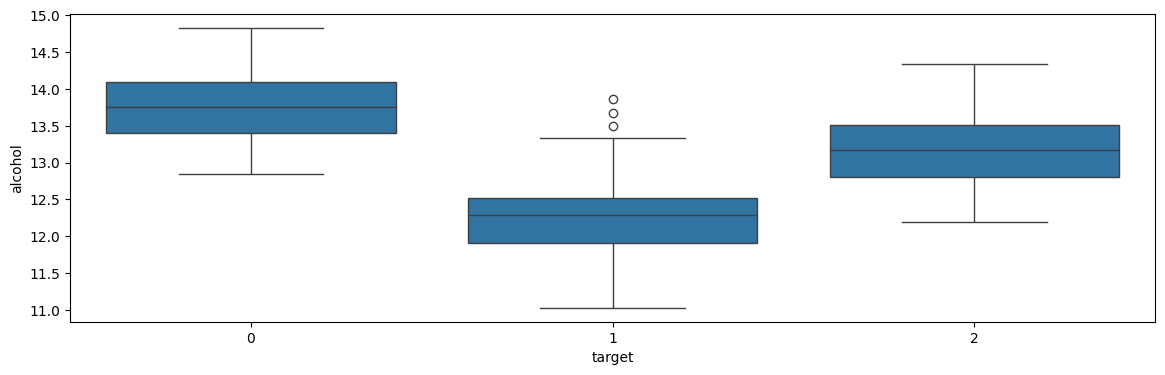

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(14,4))
sns.boxplot(data=df, x="target", y="alcohol", ax=axes)
plt.show()


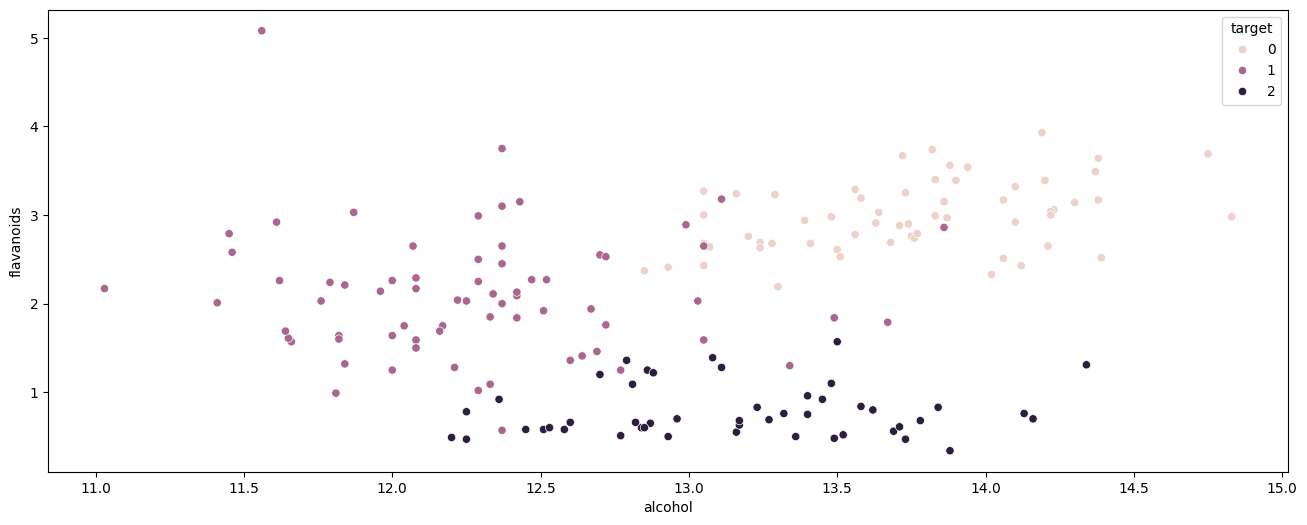

In [6]:
fig , axes = plt.subplots(figsize=(16,6))
sns.scatterplot(data=df, hue="target", x= "alcohol", y= "flavanoids", ax=axes)
plt.show()

<Axes: xlabel='color_intensity', ylabel='Count'>

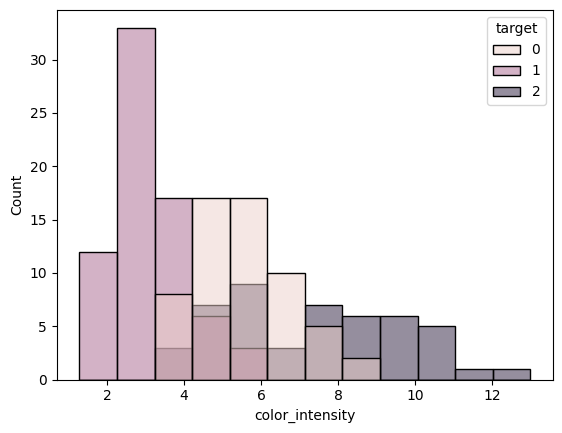

In [7]:
sns.histplot(data=df, x="color_intensity", hue="target")


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(119, 13)
(59, 13)
(119,)
(59,)


In [9]:
import mlflow
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("DT_RF_GB_GNB")
mlflow.sklearn.autolog()

models_to_test = [DecisionTreeClassifier(), RandomForestClassifier(), GradientBoostingClassifier(), GaussianNB()]

for model in models_to_test:
    model_name = type(model).__name__
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds, average="weighted")
        recall = recall_score(y_test, preds, average="weighted")
        f1 = f1_score(y_test, preds, average="weighted")


        mlflow.log_metric("accuracy score", acc)
        mlflow.log_metric("precision score", precision)
        mlflow.log_metric("recall score", recall)
        mlflow.log_metric("f1 score", f1)

        print(f"{model_name}: accuracy score: {acc}, precision score: {precision}, recall score: {recall}, f1 score: {f1} ")

DecisionTreeClassifier: accuracy score: 0.9661016949152542, precision score: 0.9687092568448501, recall score: 0.9661016949152542, f1 score: 0.9662701374215108 
RandomForestClassifier: accuracy score: 1.0, precision score: 1.0, recall score: 1.0, f1 score: 1.0 
GradientBoostingClassifier: accuracy score: 0.9152542372881356, precision score: 0.9218865143699336, recall score: 0.9152542372881356, f1 score: 0.9142031270529497 
GaussianNB: accuracy score: 1.0, precision score: 1.0, recall score: 1.0, f1 score: 1.0 
